# Problem 1: Data From yFinance

In [1]:
# Import necessary libraries
# Pandas for data manipulation: ref: https://pandas.pydata.org/
# yfinance for fetching stock data: ref: https://pypi.org/project/yfinance/
import os
from datetime import datetime
import pandas as pd 
import yfinance as yf

# Function to get stock data 
def get_data():

# List of tickers
    tickers = ['META', 'AAPL', 'AMZN', 'NFLX', 'GOOG']


    data = {}

# Fetch historical data for each ticker
    for ticker in tickers:
        stock = yf.Ticker(ticker)
        df = stock.history(period='5d', interval='1h')
        data[ticker] = df

# Combine all data into one DataFrame with a ticker column to ensure clear and easily readable 
    combined = pd.concat(data.values(), keys=data.keys(), names=['Ticker', 'Datetime'])

# Save and round to 2 decimal places
# Round function from w3schools - ref: https://www.w3schools.com/python/ref_func_round.asp
# Combine funtion from w3schools - ref: https://www.w3schools.com/python/pandas/ref_df_combine.asp
    price_cols = ['Open', 'High', 'Low', 'Close'] 
    combined[price_cols] = combined[price_cols].round(2)

# ensure output directory exists
    os.makedirs('data', exist_ok=True)

# Generate timestamped filename
# Datetime ref: https://www.w3schools.com/python/python_datetime.asp
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    filename = f"data/{timestamp}.csv"


# Save the data and combine
    combined.to_csv(filename)
    print(f" Data saved to {filename}")
    return filename,combined



# Problem 2 : Plotting Data

/tmp/ipykernel_14994/3643361325.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers,period='1mo')['Close']
[*********************100%***********************]  5 of 5 completed


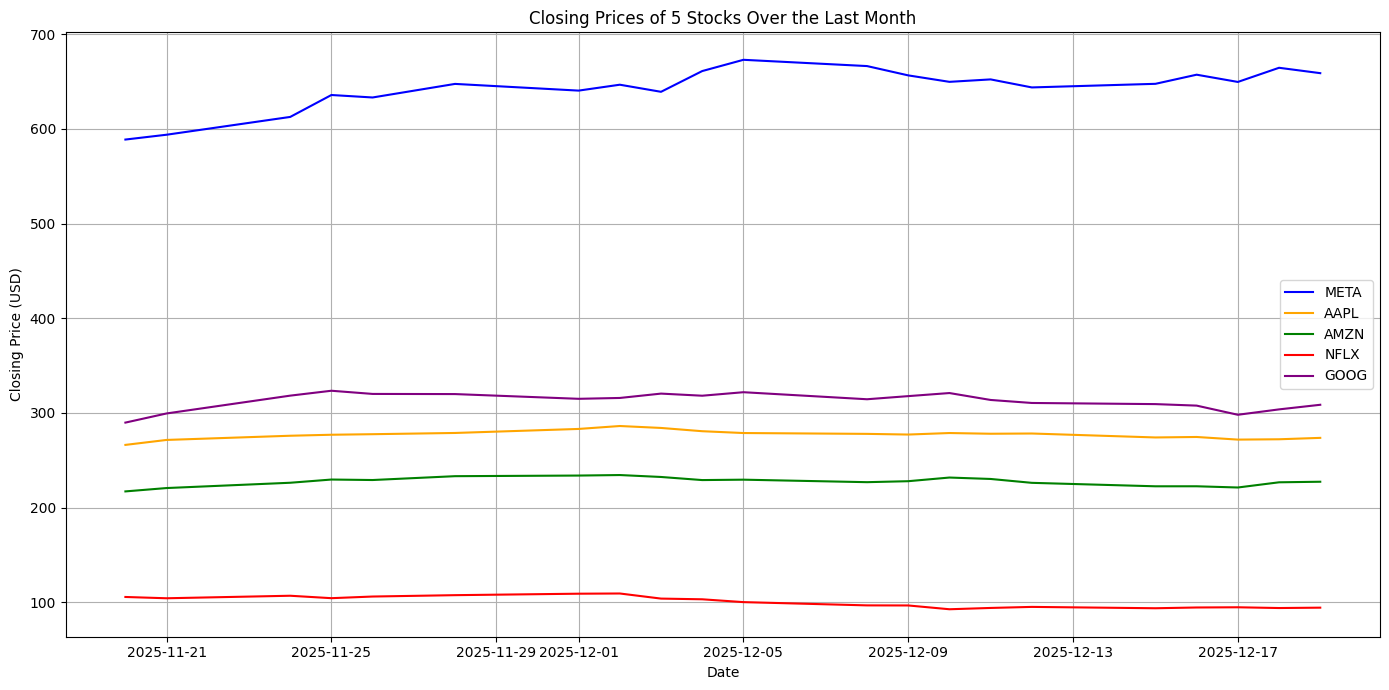

In [2]:
# Import necessary libraries
# Pandas for data manipulation: ref: https://pandas.pydata.org/
# yfinance for fetching stock data: ref: https://pypi.org/project/yfinance/
# Matplotlib for data visualization: ref: https://matplotlib.org/
import yfinance as yf
import pandas as pd 
import matplotlib.pyplot as plt

# Define Tickers
tickers = ['META', 'AAPL', 'AMZN', 'NFLX', 'GOOG']

# Download historical data for the last month
# yfinance download function - ref:https://pypi.org/project/yfinance/
df = yf.download(tickers,period='1mo')['Close']

# Plotting the closing prices
plt.figure(figsize=(14,7))
colors = ['blue', 'orange', 'green', 'red', 'purple']   

for ticker, color in zip(tickers, colors):
    plt.plot(df.index, df[ticker], label=ticker, color=color)

# Customize the plot using Matplotlib
# matplotlib - ref:https://www.w3schools.com/python/matplotlib_plotting.asp
plt.title('Closing Prices of 5 Stocks Over the Last Month')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig('stock_prices.png', dpi=300)
plt.show()
